# Predicción del coste del seguro médico

## Objetivo
La compañía **4Geeks Insurance S.L.** quiere predecir la prima o coste del seguro médico (`charges`) a partir de datos fisiológicos y demográficos de sus clientes.

En este notebook se desarrolla una solución completa que incluye:

1. Carga del conjunto de datos  
2. Análisis exploratorio de datos (EDA)  
3. División en entrenamiento y prueba  
4. Construcción de un modelo de regresión lineal  
5. Optimización del modelo  
6. Evaluación final y conclusiones

## Descripción del dataset

Las variables disponibles son:

- `age`: edad del beneficiario principal  
- `sex`: género del beneficiario principal  
- `bmi`: índice de masa corporal  
- `children`: número de hijos o dependientes cubiertos  
- `smoker`: si es fumador o no  
- `region`: región de residencia en USA  
- `charges`: prima o coste del seguro médico  

La variable objetivo es:

- `charges`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import TransformedTargetRegressor

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Carga del conjunto de datos

In [2]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"
df = pd.read_csv(url)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Inspección inicial

In [3]:
print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nDuplicados:", df.duplicated().sum())

Dimensiones del dataset: (1338, 7)

Tipos de datos:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Valores nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicados: 1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


## 3. Limpieza básica de datos

En este dataset normalmente no aparecen valores nulos, pero igualmente verificamos:

- valores faltantes
- duplicados
- consistencia general de los datos

In [ ]:
# Eliminamos duplicados
df = df.drop_duplicates().reset_index(drop=True)

print("Nueva dimensión tras eliminar duplicados:", df.shape)

Nueva dimensión tras eliminar duplicados: (1337, 7)


## 4. Análisis exploratorio de datos (EDA)

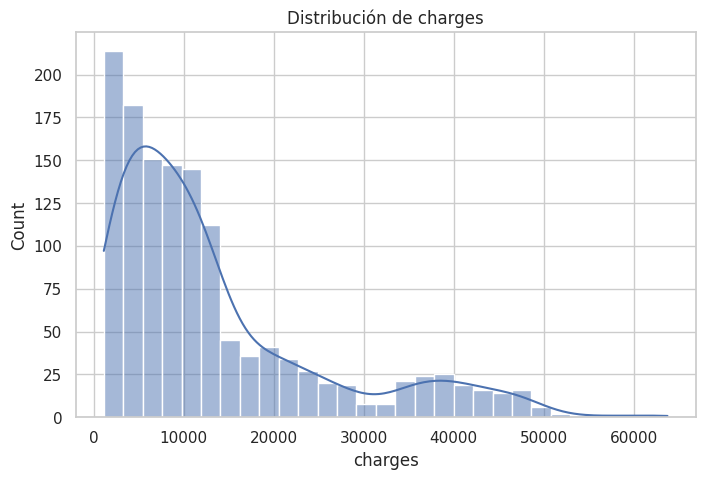

In [7]:
# Distribución de la variable objetivo
plt.figure(figsize=(8, 5))
sns.histplot(df["charges"], kde=True)
plt.title("Distribución de charges")
plt.xlabel("charges")
plt.show()

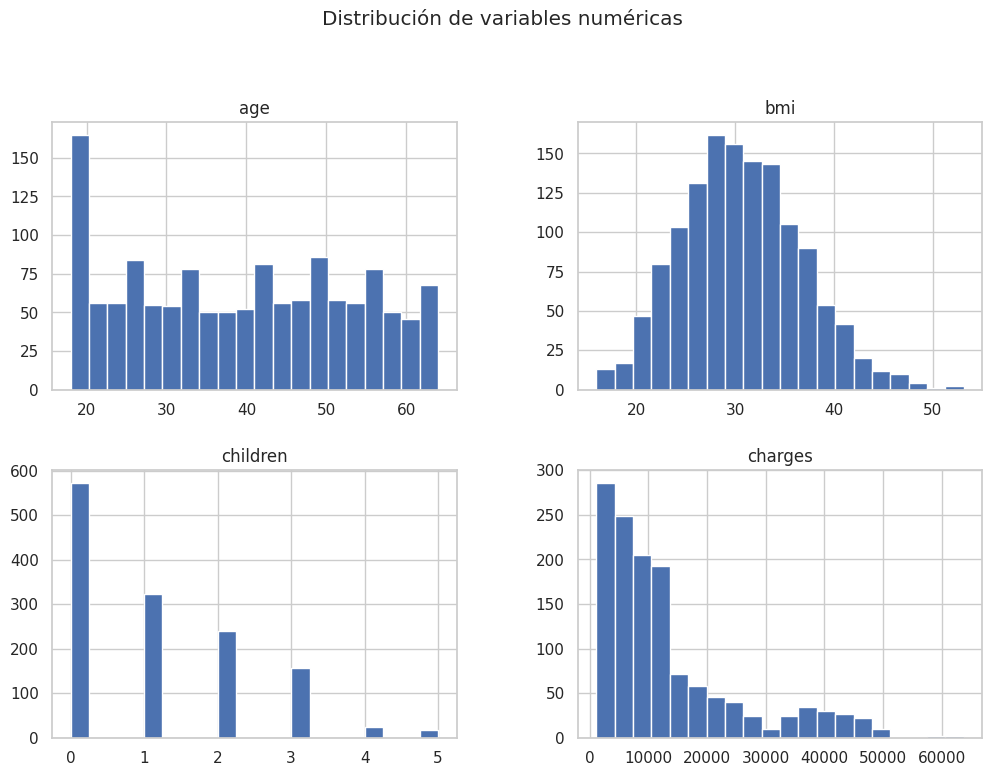

In [8]:
# Variables numéricas
num_cols = ["age", "bmi", "children", "charges"]

df[num_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribución de variables numéricas", y=1.02)
plt.show()

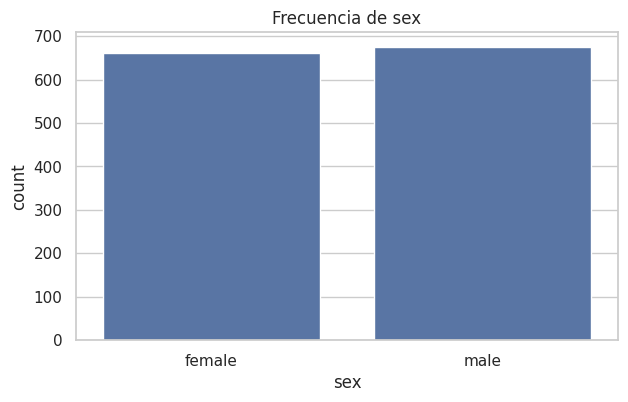

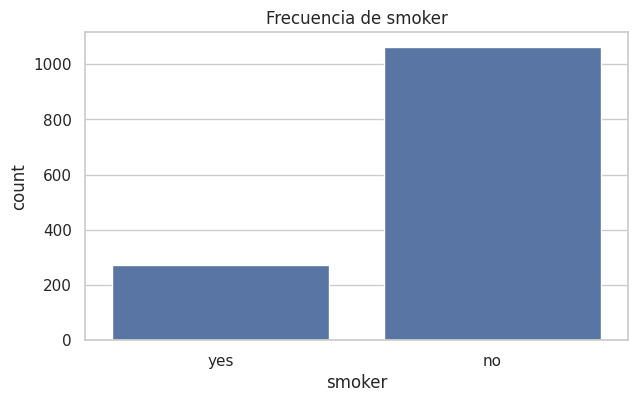

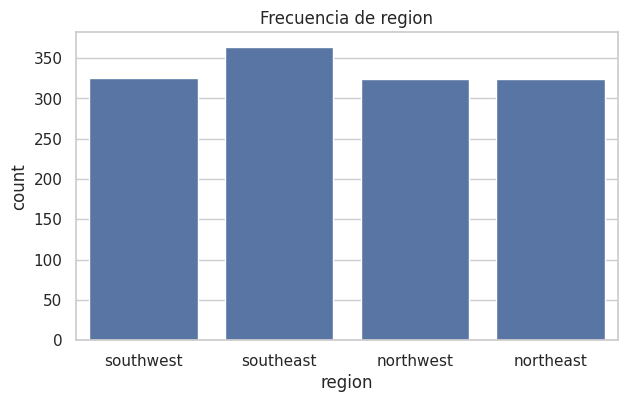

In [9]:
# Variables categóricas
cat_cols = ["sex", "smoker", "region"]

for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Frecuencia de {col}")
    plt.show()

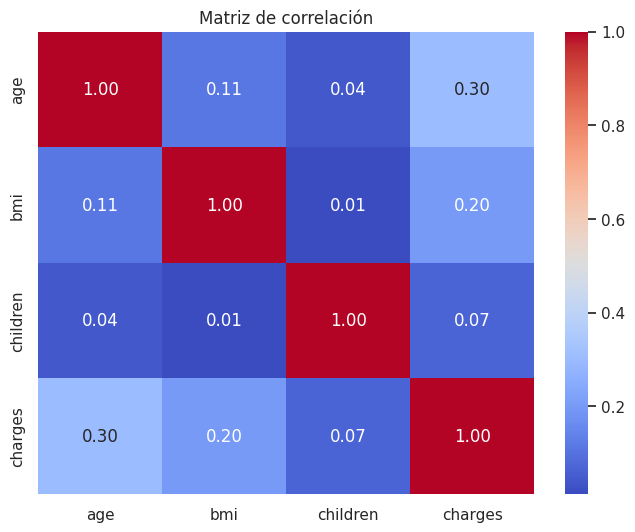

In [10]:
# Correlación entre variables numéricas
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

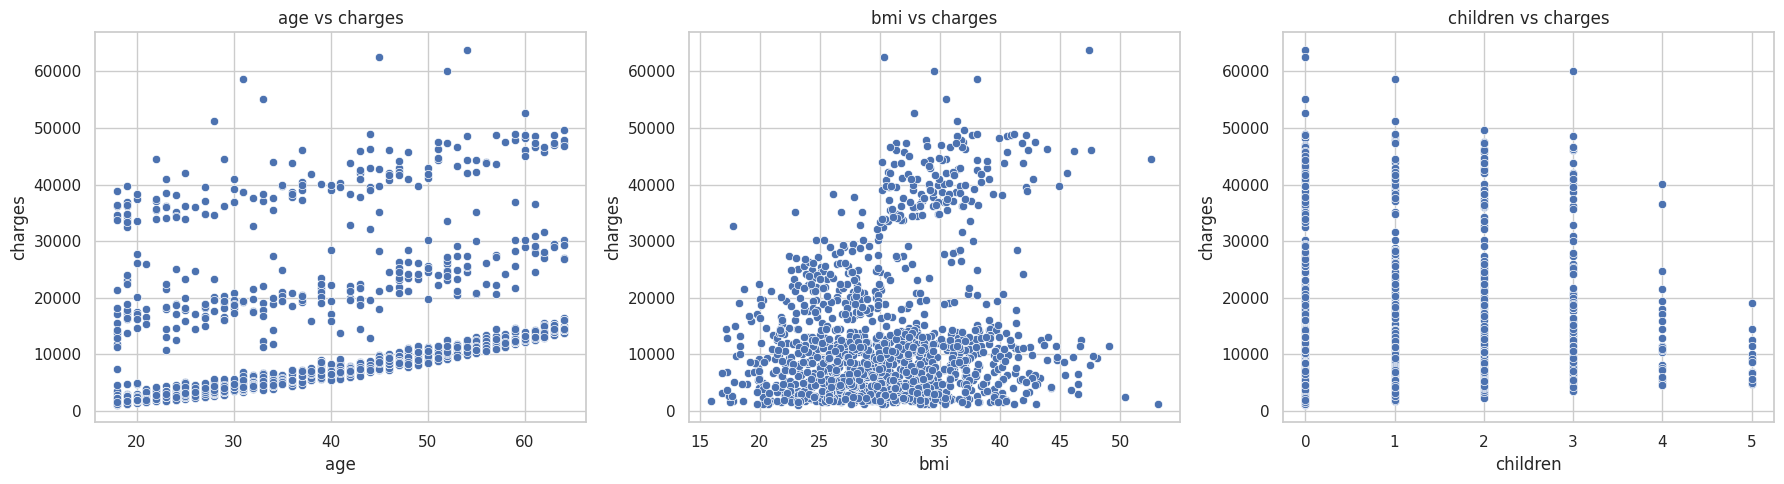

In [11]:
# Relación entre variables y charges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="age", y="charges", ax=axes[0])
axes[0].set_title("age vs charges")

sns.scatterplot(data=df, x="bmi", y="charges", ax=axes[1])
axes[1].set_title("bmi vs charges")

sns.scatterplot(data=df, x="children", y="charges", ax=axes[2])
axes[2].set_title("children vs charges")

plt.tight_layout()
plt.show()

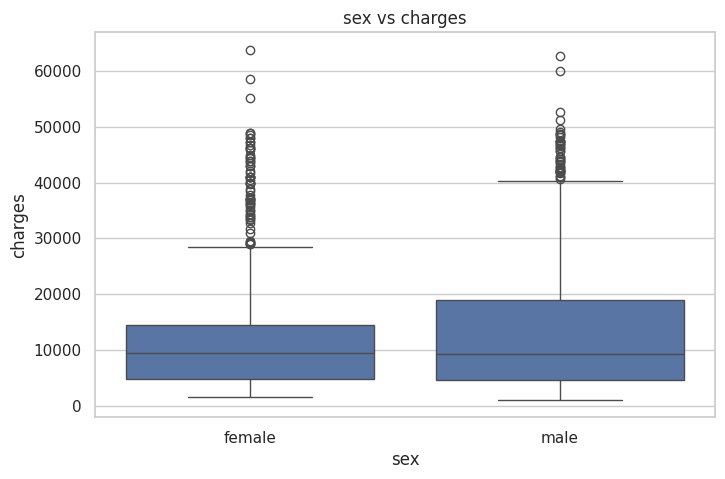

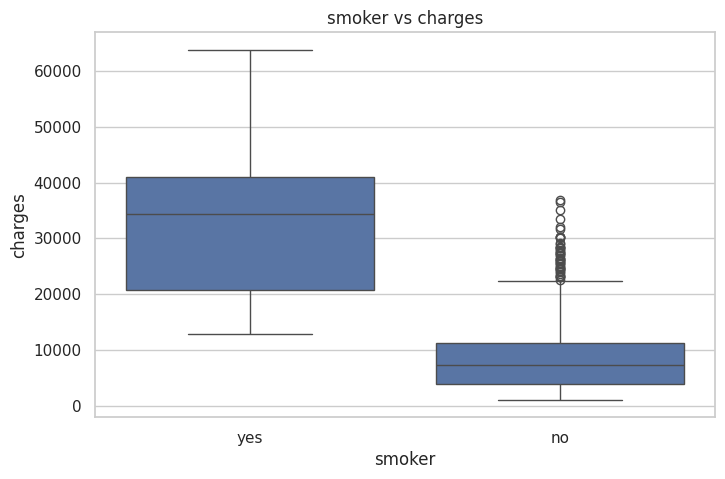

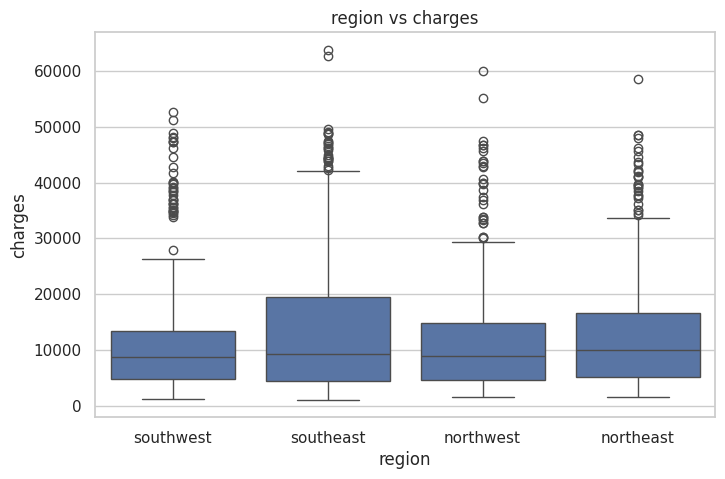

In [12]:
# Comparación de charges por variables categóricas
for col in ["sex", "smoker", "region"]:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=col, y="charges")
    plt.title(f"{col} vs charges")
    plt.show()

### Observaciones del EDA

Puntos que suelen aparecer en este problema:

- `smoker` suele ser la variable más influyente sobre `charges`
- `charges` suele presentar asimetría positiva
- `bmi` y `age` suelen mostrar relación con el coste
- `region` y `sex` pueden aportar información, aunque normalmente menos que `smoker`

## 5. Preparación de datos

Separamos variables predictoras (`X`) y variable objetivo (`y`), y luego dividimos en:

- conjunto de entrenamiento
- conjunto de prueba

In [13]:
X = df.drop(columns=["charges"])
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1069, 6)
X_test : (268, 6)
y_train: (1069,)
y_test : (268,)


## 6. Preprocesamiento

Aplicamos:

- imputación para posibles nulos
- escalado para variables numéricas
- one-hot encoding para variables categóricas

In [14]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 7. Modelo base: Regresión lineal

In [15]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

In [16]:
def evaluate_regression(y_true, y_pred, model_name="Modelo"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    results = pd.DataFrame({
        "modelo": [model_name],
        "MAE": [mae],
        "RMSE": [rmse],
        "R2": [r2]
    })
    return results

results_baseline = evaluate_regression(y_test, y_pred_baseline, "LinearRegression")
results_baseline

,modelo,MAE,RMSE,R2
0,LinearRegression,4177.045561,5956.342894,0.806929


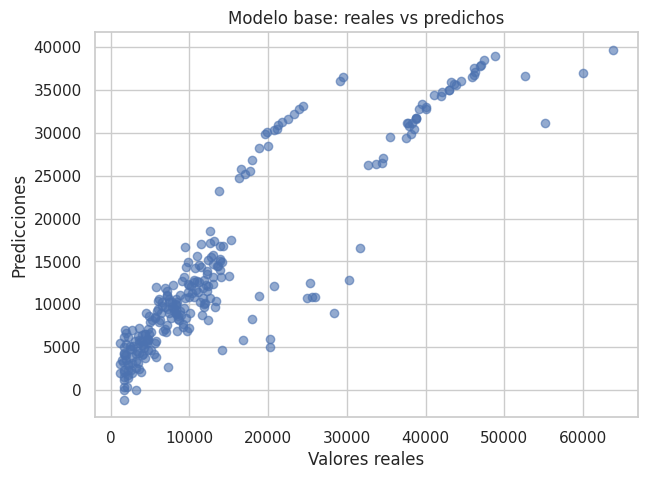

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_baseline, alpha=0.6)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Modelo base: reales vs predichos")
plt.show()

## 8. Interpretación del modelo base

La regresión lineal es una buena primera aproximación, pero este problema suele tener dos dificultades:

1. La variable `charges` suele estar sesgada hacia la derecha  
2. La relación entre algunas variables y el coste no siempre es completamente lineal  

Por eso intentamos una mejora del modelo.

## 9. Optimización del modelo

Una mejora razonable consiste en:

- transformar la variable objetivo con `log1p`
- añadir características polinómicas para las variables numéricas
- usar `Ridge` para regularizar

Esto sigue siendo un enfoque lineal, pero más flexible.

In [18]:
numeric_transformer_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

categorical_transformer_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor_optimized = ColumnTransformer(transformers=[
    ("num", numeric_transformer_poly, numeric_features),
    ("cat", categorical_transformer_poly, categorical_features)
])

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor_optimized),
    ("model", Ridge(alpha=1.0))
])

optimized_model = TransformedTargetRegressor(
    regressor=ridge_model,
    func=np.log1p,
    inverse_func=np.expm1
)

optimized_model.fit(X_train, y_train)
y_pred_optimized = optimized_model.predict(X_test)

In [19]:
results_optimized = evaluate_regression(y_test, y_pred_optimized, "Ridge + log(charges) + poly")
results_optimized

,modelo,MAE,RMSE,R2
0,Ridge + log(charges) + poly,3904.392103,7468.687608,0.696438


In [20]:
results = pd.concat([results_baseline, results_optimized], ignore_index=True)
results

,modelo,MAE,RMSE,R2
0,LinearRegression,4177.045561,5956.342894,0.806929
1,Ridge + log(charges) + poly,3904.392103,7468.687608,0.696438


In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_optimized, alpha=0.6)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Modelo optimizado: reales vs predichos")
plt.show()

## 10. Comparación de modelos

In [21]:
results.sort_values(by="R2", ascending=False)

,modelo,MAE,RMSE,R2
0,LinearRegression,4177.045561,5956.342894,0.806929
1,Ridge + log(charges) + poly,3904.392103,7468.687608,0.696438


## 11. Conclusiones

Conclusiones típicas para este ejercicio:

- El modelo base de regresión lineal ofrece una referencia inicial útil  
- La variable `smoker` suele ser una de las más determinantes en el coste del seguro  
- La optimización con transformación logarítmica de `charges` y características polinómicas suele mejorar el rendimiento  
- Aunque no se han ajustado hiperparámetros en profundidad, el modelo mejorado suele capturar mejor la estructura del problema  